In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import torch.nn.functional as F
from sklearn.metrics import classification_report, f1_score


df = pd.read_csv("data/indonesia_dataset.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [24]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [18]:
X = df.drop('label', axis=1)
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

print("X shape:", X_reshaped.shape)
print("y shape:", y_encoded.shape)

X shape: (2200, 1, 7)
y shape: (2200,)


In [19]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_classes=2, dropout_rate=0.3):
        super(LSTMClassifier, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        
        out = lstm_out[:, -1, :]
        
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

num_features = X_reshaped.shape[2]
num_classes = len(np.unique(y_encoded))

model = LSTMClassifier(input_size=num_features, hidden_size=128, num_classes=num_classes, dropout_rate=0.3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

print(model)

LSTMClassifier(
  (lstm): LSTM(7, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=22, bias=True)
)


In [20]:
# Setup device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# First split: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42
)

# Second split: validation split (20% of training data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Convert Data to PyTorch Tensors & DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Custom Early Stopping Helper
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())  # Save best weights
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Model Training Loop
epochs = 100
early_stop = EarlyStopping(patience=10)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels).item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # Validation Phase
    model.eval()
    val_running_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels).item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = correct_val / total_val

    # Store history metrics
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:03d}/{epochs} - "
          f"loss: {epoch_train_loss:.4f} - acc: {epoch_train_acc:.4f} - "
          f"val_loss: {epoch_val_loss:.4f} - val_acc: {epoch_val_acc:.4f}")

    # Check Early Stopping
    early_stop(epoch_val_loss, model)
    if early_stop.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

if early_stop.best_weights is not None:
    model.load_state_dict(early_stop.best_weights)
    print("Restored model weights from the best epoch.")

Epoch 001/100 - loss: 3.0879 - acc: 0.0611 - val_loss: 3.0848 - val_acc: 0.0597
Epoch 002/100 - loss: 3.0497 - acc: 0.0916 - val_loss: 2.9996 - val_acc: 0.1676
Epoch 003/100 - loss: 2.8285 - acc: 0.1655 - val_loss: 2.5933 - val_acc: 0.2188
Epoch 004/100 - loss: 2.3181 - acc: 0.3310 - val_loss: 2.0417 - val_acc: 0.5256
Epoch 005/100 - loss: 1.8089 - acc: 0.4943 - val_loss: 1.5649 - val_acc: 0.6364
Epoch 006/100 - loss: 1.3828 - acc: 0.6420 - val_loss: 1.1599 - val_acc: 0.7812
Epoch 007/100 - loss: 1.0689 - acc: 0.7159 - val_loss: 0.9251 - val_acc: 0.8182
Epoch 008/100 - loss: 0.8641 - acc: 0.7834 - val_loss: 0.7349 - val_acc: 0.8665
Epoch 009/100 - loss: 0.7152 - acc: 0.8196 - val_loss: 0.5997 - val_acc: 0.8636
Epoch 010/100 - loss: 0.5992 - acc: 0.8388 - val_loss: 0.5186 - val_acc: 0.8864
Epoch 011/100 - loss: 0.5265 - acc: 0.8643 - val_loss: 0.4315 - val_acc: 0.9091
Epoch 012/100 - loss: 0.4739 - acc: 0.8643 - val_loss: 0.3789 - val_acc: 0.9375
Epoch 013/100 - loss: 0.4341 - acc: 0.87

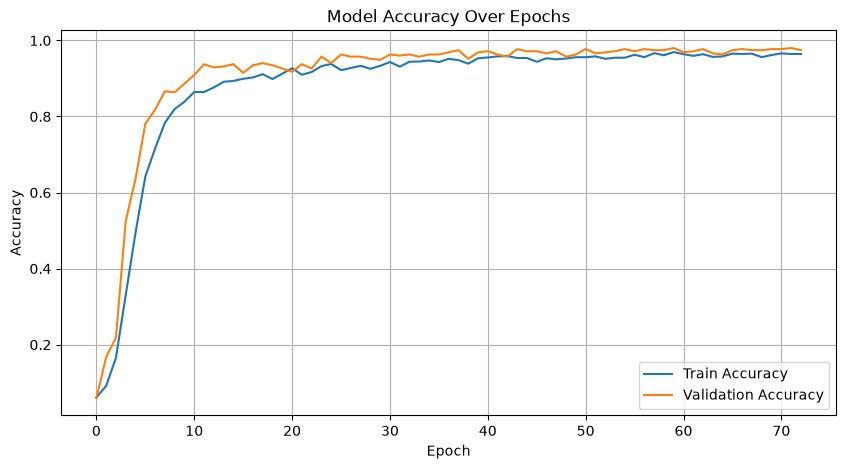

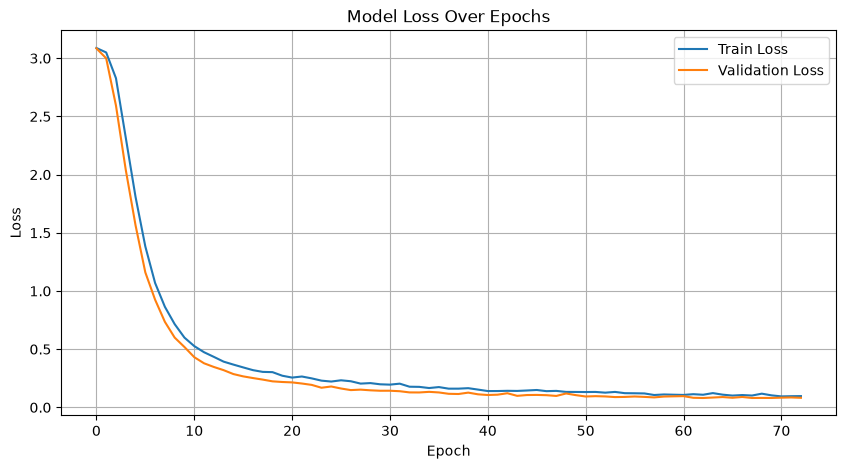

In [21]:
# Accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        
        # Softmax converts raw logits into probabilities
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

y_pred_probs = np.array(all_probs)
y_pred = np.array(all_preds)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1 Score:", round(f1, 4))

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      1.00      0.94        17
      grapes       1.00      1.00      1.00        14
        jute       0.90      0.83      0.86        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.73      1.00      0.85        11
       maize       1.00      0.90      0.95        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
    